In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from ucimlrepo import fetch_ucirepo
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

  


In [54]:
# fetch dataset 
metro_traffic_volume = fetch_ucirepo(id=492) 

traffic_df = metro_traffic_volume.data.original
traffic_df


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918
...,...,...,...,...,...,...,...,...,...
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450


In [55]:

# ---- Manually add descriptions for each feature here ----
descriptions = {
    "holiday": "Whether the day is a US holiday",
    "temp": "Average temperature in Kelvin",
    "rain_1h": "Rainfall amount in last 1 hour (mm)",
    "snow_1h": "Snow amount in last 1 hour (mm)",
    "clouds_all": "Cloud cover (%)",
    "weather_main": "Main weather condition",
    "weather_description": "Detailed weather condition",
    "date_time": "Timestamp of observation",
    "traffic_volume": "Traffic volume recorded"
}

# ---- Build the table ----
rows = []
for col in traffic_df.columns:
    data_type = str(traffic_df[col].dtype)
    description = descriptions.get(col, " - ")
    unique_vals = traffic_df[col].nunique()
    
    # Example values (first 3 unique)
    example_vals = traffic_df[col].dropna().unique()[:3]
    example_vals = ", ".join(map(str, example_vals))
    
    rows.append([col, data_type, description, unique_vals, example_vals])

# Create DataFrame
table_df = pd.DataFrame(rows, columns=[
    "Feature / Variable",
    "Data Type",
    "Description",
    "Number of Unique Values",
    "Example Values"
])

# ---- Convert to Markdown ----
markdown_output = table_df.to_markdown(index=False)

print(markdown_output)


| Feature / Variable   | Data Type   | Description                         |   Number of Unique Values | Example Values                                                |
|:---------------------|:------------|:------------------------------------|--------------------------:|:--------------------------------------------------------------|
| holiday              | object      | Whether the day is a US holiday     |                        11 | Columbus Day, Veterans Day, Thanksgiving Day                  |
| temp                 | float64     | Average temperature in Kelvin       |                      5843 | 288.28, 289.36, 289.58                                        |
| rain_1h              | float64     | Rainfall amount in last 1 hour (mm) |                       372 | 0.0, 0.25, 0.57                                               |
| snow_1h              | float64     | Snow amount in last 1 hour (mm)     |                        12 | 0.0, 0.51, 0.32                                   

In [56]:
# First 5 rows
print("First 5 Rows:")
display(traffic_df.head())

# Last 5 rows
print("Last 5 Rows:")
display(traffic_df.tail())

# Random sample of 5 rows
print("Random sample of 5 Rows:")
display(traffic_df.sample(5, random_state=42))

First 5 Rows:


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


Last 5 Rows:


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450
48203,NaN,282.12,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 23:00:00,954


Random sample of 5 Rows:


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
35748,NaN,289.49,0.0,0.0,1,Fog,fog,2017-07-28 07:00:00,6364
147,NaN,279.35,0.0,0.0,1,Clear,sky is clear,2012-10-08 21:00:00,2030
24362,NaN,291.39,0.0,0.0,36,Clouds,scattered clouds,2016-06-22 00:00:00,708
35495,NaN,294.02,0.0,0.0,90,Thunderstorm,thunderstorm,2017-07-19 22:00:00,2029
11010,NaN,268.69,0.0,0.0,64,Mist,mist,2013-12-27 09:00:00,3734


In [57]:
#check data types
traffic_df.dtypes

holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
traffic_volume           int64
dtype: object

In [58]:
# Convert "date_time" column to datetime format
traffic_df["date_time"] = pd.to_datetime(traffic_df["date_time"])
traffic_df.sample(5)

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
11982,NaN,264.45,0.0,0.0,90,Clouds,overcast clouds,2014-02-03 15:00:00,5554
12005,NaN,260.51,0.0,0.0,75,Clouds,broken clouds,2014-02-04 14:00:00,4913
39666,NaN,269.72,0.0,0.0,90,Fog,fog,2017-12-11 01:00:00,281
6228,NaN,291.16,0.0,0.0,1,Mist,mist,2013-05-21 00:00:00,659
4184,NaN,274.62,0.0,0.0,90,Haze,haze,2013-03-09 23:00:00,1755


## Inspect Timeframes

In [59]:
# check the oldest and newest timestamps
print("Oldest timestamp:", traffic_df["date_time"].min())
print("Newest timestamp:", traffic_df["date_time"].max())


Oldest timestamp: 2012-10-02 09:00:00
Newest timestamp: 2018-09-30 23:00:00


In [60]:
# calculate difference betweeen oldeste and newest timestamps
print({traffic_df['date_time'].min(), traffic_df['date_time'].max()})
print(len(traffic_df))

{Timestamp('2018-09-30 23:00:00'), Timestamp('2012-10-02 09:00:00')}
48204


In [61]:
# calculate expected number of hourly entries
len(pd.date_range(start=traffic_df['date_time'].min(), end=traffic_df['date_time'].max(), freq='h'))

52551

In [62]:
# create time skeleton to identify gaps

skeleton = pd.date_range(start = traffic_df['date_time'].min(), end = traffic_df['date_time'].max(), freq='h')
len(skeleton)

52551

In [63]:
# merging skeleton with original data to identify missing timestamps
skeleton_df = pd.DataFrame(skeleton, columns = ['date_time'])

In [64]:
df_full = pd.merge(skeleton_df, traffic_df, on = 'date_time', how = 'left')

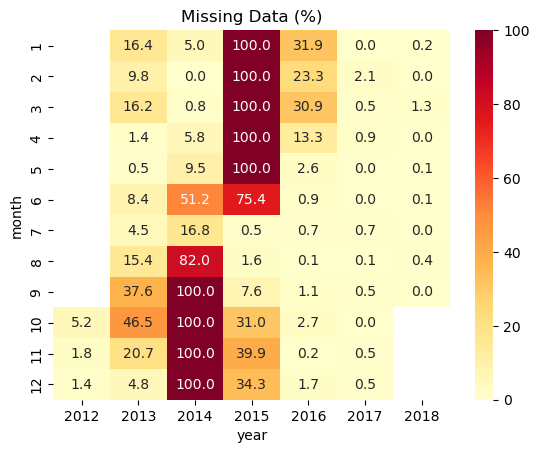

In [65]:
# Calculate fraction of missing data for each year-month
missing_heatmap_data = df_full.copy()
missing_heatmap_data['year'] = missing_heatmap_data['date_time'].dt.year
missing_heatmap_data['month'] = missing_heatmap_data['date_time'].dt.month
missing_heatmap_data['is_missing'] = missing_heatmap_data['traffic_volume'].isna()

missing_heatmap_data = (
    missing_heatmap_data
    .groupby(['year', 'month'], as_index=False)
    ['is_missing']
    .mean()
    .assign(missing_pct=lambda x: round(x['is_missing'] * 100, 1))
    [['year', 'month', 'missing_pct']]
)

sns.heatmap(missing_heatmap_data.pivot_table(index='month', columns='year', values='missing_pct'), 
            annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Missing Data (%)')
plt.show()

## Selecting 2017 as an appropriate Time Frame

In [66]:
# Filter data for the year 2017
traffic2017_df = traffic_df[traffic_df["date_time"].dt.year == 2017].copy()
traffic2017_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10605 entries, 29650 to 40254
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              12 non-null     object        
 1   temp                 10605 non-null  float64       
 2   rain_1h              10605 non-null  float64       
 3   snow_1h              10605 non-null  float64       
 4   clouds_all           10605 non-null  int64         
 5   weather_main         10605 non-null  object        
 6   weather_description  10605 non-null  object        
 7   date_time            10605 non-null  datetime64[ns]
 8   traffic_volume       10605 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 828.5+ KB


In [67]:
traffic2017_df

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
29650,NaN,269.75,0.0,0.0,75,Clouds,broken clouds,2017-01-01 00:00:00,1848
29651,NaN,269.95,0.0,0.0,1,Clear,sky is clear,2017-01-01 01:00:00,1806
29652,NaN,269.75,0.0,0.0,1,Clear,sky is clear,2017-01-01 02:00:00,1211
29653,NaN,269.65,0.0,0.0,40,Clouds,scattered clouds,2017-01-01 03:00:00,794
29654,NaN,269.48,0.0,0.0,1,Clear,sky is clear,2017-01-01 04:00:00,500
...,...,...,...,...,...,...,...,...,...
40250,NaN,249.84,0.0,0.0,1,Clear,sky is clear,2017-12-31 19:00:00,2995
40251,NaN,249.79,0.0,0.0,5,Clear,sky is clear,2017-12-31 20:00:00,2731
40252,NaN,249.61,0.0,0.0,5,Clear,sky is clear,2017-12-31 21:00:00,2483
40253,NaN,249.50,0.0,0.0,1,Clear,sky is clear,2017-12-31 22:00:00,2041


In [68]:
# drop irrelevant or empty columns
#traffic2017_df = traffic2017_df.drop(columns=["holiday"])
#traffic2017_df.info()

In [69]:
# Convert temp from Kelvin to Celsius and overwrite the column
traffic2017_df['temp'] = (traffic2017_df['temp'] - 273.15).round(2)

# Display first few rows to check
traffic2017_df[['temp']].head()



,temp
29650,-3.40
29651,-3.20
29652,-3.40
29653,-3.50
29654,-3.67


In [70]:
# drop rain_1h and snow_1h columns due to no data
traffic2017_df = traffic2017_df.drop(columns=["rain_1h", "snow_1h"])

In [71]:
# Get summary statistics for numeric columns only
numeric_summary = traffic2017_df.select_dtypes(include='number').describe().round(0).astype(int)
display(numeric_summary)
print(numeric_summary.to_markdown())


,temp,clouds_all,traffic_volume
count,10605,10605,10605
mean,8,50,3341
std,12,40,1987
min,-27,0,186
25%,0,1,1292
50%,9,75,3530
75%,18,90,4984
max,34,92,7280


|       |   temp |   clouds_all |   traffic_volume |
|:------|-------:|-------------:|-----------------:|
| count |  10605 |        10605 |            10605 |
| mean  |      8 |           50 |             3341 |
| std   |     12 |           40 |             1987 |
| min   |    -27 |            0 |              186 |
| 25%   |      0 |            1 |             1292 |
| 50%   |      9 |           75 |             3530 |
| 75%   |     18 |           90 |             4984 |
| max   |     34 |           92 |             7280 |


In [72]:
import pandas as pd

# Example numeric columns: target first, then predictors
numeric_columns = ['traffic_volume', 'temp', 'clouds_all']

# Subset the dataframe
df_numeric = traffic2017_df[numeric_columns]

# Create an empty DataFrame with columns set
desc_stats = pd.DataFrame(columns=df_numeric.columns, index=[
    'Count', 'Mean', 'Standard Deviation', 'Min', '25%', '50%', '75%', 'Max', 'Variance', 'Dispersion Index'
])

# Fill in statistics
desc_stats.loc['Count'] = df_numeric.count()
desc_stats.loc['Mean'] = df_numeric.mean()
desc_stats.loc['Standard Deviation'] = df_numeric.std()
desc_stats.loc['Min'] = df_numeric.min()
desc_stats.loc['25%'] = df_numeric.quantile(0.25)
desc_stats.loc['50%'] = df_numeric.median()
desc_stats.loc['75%'] = df_numeric.quantile(0.75)
desc_stats.loc['Max'] = df_numeric.max()
desc_stats.loc['Variance'] = df_numeric.var()
desc_stats.loc['Dispersion Index'] = df_numeric.var() / df_numeric.mean()

# Round values for readability
desc_stats = desc_stats.round(2)

# Convert to Markdown
markdown_table = desc_stats.to_markdown()
print(markdown_table)


|                    |   traffic_volume |        temp |   clouds_all |
|:-------------------|-----------------:|------------:|-------------:|
| Count              |  10605           | 10605       |   10605      |
| Mean               |   3340.7         |     8.31331 |      50.0053 |
| Standard Deviation |   1986.51        |    11.5458  |      39.5123 |
| Min                |    186           |   -27       |       0      |
| 25%                |   1292           |     0.13    |       1      |
| 50%                |   3530           |     9.2     |      75      |
| 75%                |   4984           |    17.6     |      90      |
| Max                |   7280           |    33.87    |      92      |
| Variance           |      3.94621e+06 |   133.306   |    1561.22   |
| Dispersion Index   |   1181.25        |    16.0352  |      31.2212 |


In [73]:
# List of categorical columns
cat_cols = ['holiday', 'weather_main', 'weather_description']

# Print unique values for each column
for col in cat_cols:
    print(f"Unique values in '{col}':")
    print(traffic2017_df[col].unique())
    print("-" * 40)

Unique values in 'holiday':
[nan 'New Years Day' 'Martin Luther King Jr Day' 'Washingtons Birthday'
 'Memorial Day' 'Independence Day' 'State Fair' 'Labor Day' 'Columbus Day'
 'Veterans Day' 'Thanksgiving Day' 'Christmas Day']
----------------------------------------
Unique values in 'weather_main':
['Clouds' 'Clear' 'Snow' 'Mist' 'Haze' 'Rain' 'Drizzle' 'Fog'
 'Thunderstorm' 'Smoke']
----------------------------------------
Unique values in 'weather_description':
['broken clouds' 'sky is clear' 'scattered clouds' 'few clouds'
 'overcast clouds' 'light snow' 'mist' 'haze' 'light rain'
 'heavy intensity drizzle' 'drizzle' 'light intensity drizzle' 'snow'
 'fog' 'heavy snow' 'moderate rain' 'Sky is Clear' 'light rain and snow'
 'proximity shower rain' 'proximity thunderstorm' 'heavy intensity rain'
 'thunderstorm with light rain' 'proximity thunderstorm with rain'
 'thunderstorm with light drizzle' 'proximity thunderstorm with drizzle'
 'thunderstorm' 'sleet' 'light intensity shower rain

In [74]:
traffic2017_df['holiday'] = traffic2017_df['holiday'].notna().astype(int)
traffic2017_df

,holiday,temp,clouds_all,weather_main,weather_description,date_time,traffic_volume
29650,0,-3.40,75,Clouds,broken clouds,2017-01-01 00:00:00,1848
29651,0,-3.20,1,Clear,sky is clear,2017-01-01 01:00:00,1806
29652,0,-3.40,1,Clear,sky is clear,2017-01-01 02:00:00,1211
29653,0,-3.50,40,Clouds,scattered clouds,2017-01-01 03:00:00,794
29654,0,-3.67,1,Clear,sky is clear,2017-01-01 04:00:00,500
...,...,...,...,...,...,...,...
40250,0,-23.31,1,Clear,sky is clear,2017-12-31 19:00:00,2995
40251,0,-23.36,5,Clear,sky is clear,2017-12-31 20:00:00,2731
40252,0,-23.54,5,Clear,sky is clear,2017-12-31 21:00:00,2483
40253,0,-23.65,1,Clear,sky is clear,2017-12-31 22:00:00,2041


In [75]:
# Map weather_main into broader categories
weather_map = {
    'Clouds': 'Cloudy',
    'Mist': 'Cloudy',
    'Haze': 'Cloudy',
    'Fog': 'Cloudy',
    'Clear': 'Clear',
    'Rain': 'Rain',
    'Drizzle': 'Rain',
    'Snow': 'Snow',
    'Sleet': 'Snow',
    'Thunderstorm': 'Storm',
    'Smoke': 'Other'
}

traffic2017_df['weather_group'] = traffic2017_df['weather_main'].map(weather_map)

# One-hot encode the original weather_main column, drop first category (Clear)
weather_dummies = pd.get_dummies(traffic2017_df['weather_group'], prefix='weather', drop_first=True)

# Concatenate to your original dataframe
traffic2017_df = pd.concat([traffic2017_df, weather_dummies], axis=1)

# Convert dummy columns to int
traffic2017_df[weather_dummies.columns] = traffic2017_df[weather_dummies.columns].astype(int)
traffic2017_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10605 entries, 29650 to 40254
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              10605 non-null  int32         
 1   temp                 10605 non-null  float64       
 2   clouds_all           10605 non-null  int64         
 3   weather_main         10605 non-null  object        
 4   weather_description  10605 non-null  object        
 5   date_time            10605 non-null  datetime64[ns]
 6   traffic_volume       10605 non-null  int64         
 7   weather_group        10605 non-null  object        
 8   weather_Cloudy       10605 non-null  int32         
 9   weather_Other        10605 non-null  int32         
 10  weather_Rain         10605 non-null  int32         
 11  weather_Snow         10605 non-null  int32         
 12  weather_Storm        10605 non-null  int32         
dtypes: datetime64[ns](1), float64(1)

In [76]:
# Extract Hour, Month, Day
traffic2017_df['Hour'] = traffic2017_df['date_time'].dt.hour
traffic2017_df['Month'] = traffic2017_df['date_time'].dt.month
traffic2017_df['Day'] = traffic2017_df['date_time'].dt.day

# Insert the columns after 'date'
date_idx = traffic2017_df.columns.get_loc('date_time')  # get index of 'date' column

traffic2017_df.insert(date_idx + 1, 'Hour', traffic2017_df.pop('Hour'))
traffic2017_df.insert(date_idx + 2, 'Month', traffic2017_df.pop('Month'))
traffic2017_df.insert(date_idx + 3, 'Day', traffic2017_df.pop('Day'))

traffic2017_df.head()

,holiday,temp,clouds_all,weather_main,weather_description,date_time,Hour,Month,Day,traffic_volume,weather_group,weather_Cloudy,weather_Other,weather_Rain,weather_Snow,weather_Storm
29650,0,-3.40,75,Clouds,broken clouds,2017-01-01 00:00:00,0,1,1,1848,Cloudy,1,0,0,0,0
29651,0,-3.20,1,Clear,sky is clear,2017-01-01 01:00:00,1,1,1,1806,Clear,0,0,0,0,0
29652,0,-3.40,1,Clear,sky is clear,2017-01-01 02:00:00,2,1,1,1211,Clear,0,0,0,0,0
29653,0,-3.50,40,Clouds,scattered clouds,2017-01-01 03:00:00,3,1,1,794,Cloudy,1,0,0,0,0
29654,0,-3.67,1,Clear,sky is clear,2017-01-01 04:00:00,4,1,1,500,Clear,0,0,0,0,0


In [77]:
# Hour of day (0-23)
traffic2017_df['hour_sin'] = np.sin(2 * np.pi * traffic2017_df['date_time'].dt.hour / 24)
traffic2017_df['hour_cos'] = np.cos(2 * np.pi * traffic2017_df['date_time'].dt.hour / 24)

# Day of week (0=Monday, 6=Sunday)
traffic2017_df['weekday_sin'] = np.sin(2 * np.pi * traffic2017_df['date_time'].dt.weekday / 7)
traffic2017_df['weekday_cos'] = np.cos(2 * np.pi * traffic2017_df['date_time'].dt.weekday / 7)

# Month of year (1-12) 
traffic2017_df['month_sin'] = np.sin(2 * np.pi * (traffic2017_df['date_time'].dt.month - 1) / 12)
traffic2017_df['month_cos'] = np.cos(2 * np.pi * (traffic2017_df['date_time'].dt.month - 1) / 12)


# Check result
traffic2017_df

,holiday,temp,clouds_all,weather_main,weather_description,date_time,Hour,Month,Day,traffic_volume,...,weather_Other,weather_Rain,weather_Snow,weather_Storm,hour_sin,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos
29650,0,-3.40,75,Clouds,broken clouds,2017-01-01 00:00:00,0,1,1,1848,...,0,0,0,0,0.000000,1.000000,-0.781831,0.62349,0.0,1.000000
29651,0,-3.20,1,Clear,sky is clear,2017-01-01 01:00:00,1,1,1,1806,...,0,0,0,0,0.258819,0.965926,-0.781831,0.62349,0.0,1.000000
29652,0,-3.40,1,Clear,sky is clear,2017-01-01 02:00:00,2,1,1,1211,...,0,0,0,0,0.500000,0.866025,-0.781831,0.62349,0.0,1.000000
29653,0,-3.50,40,Clouds,scattered clouds,2017-01-01 03:00:00,3,1,1,794,...,0,0,0,0,0.707107,0.707107,-0.781831,0.62349,0.0,1.000000
29654,0,-3.67,1,Clear,sky is clear,2017-01-01 04:00:00,4,1,1,500,...,0,0,0,0,0.866025,0.500000,-0.781831,0.62349,0.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40250,0,-23.31,1,Clear,sky is clear,2017-12-31 19:00:00,19,12,31,2995,...,0,0,0,0,-0.965926,0.258819,-0.781831,0.62349,-0.5,0.866025
40251,0,-23.36,5,Clear,sky is clear,2017-12-31 20:00:00,20,12,31,2731,...,0,0,0,0,-0.866025,0.500000,-0.781831,0.62349,-0.5,0.866025
40252,0,-23.54,5,Clear,sky is clear,2017-12-31 21:00:00,21,12,31,2483,...,0,0,0,0,-0.707107,0.707107,-0.781831,0.62349,-0.5,0.866025
40253,0,-23.65,1,Clear,sky is clear,2017-12-31 22:00:00,22,12,31,2041,...,0,0,0,0,-0.500000,0.866025,-0.781831,0.62349,-0.5,0.866025


In [78]:
# Extract day-only format
traffic2017_df['date'] = traffic2017_df['date_time'].dt.date

# Daily totals – you can decide min, max, or mean
daily_total = traffic2017_df.groupby('date')['traffic_volume'].sum()

# Find the highest traffic day
highest_day = daily_total.idxmax(), daily_total.max()

# Find the lowest traffic day
lowest_day = daily_total.idxmin(), daily_total.min()

highest_day, lowest_day


((datetime.date(2017, 5, 1), 248731), (datetime.date(2017, 12, 25), 48355))

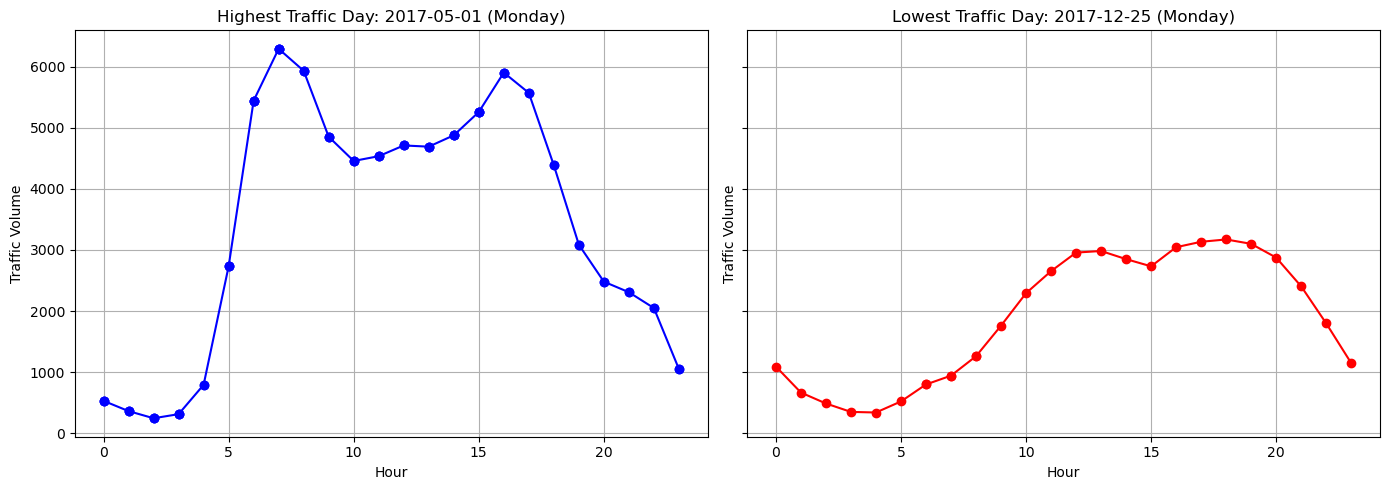

In [79]:

# Extract the dates
highest_date = highest_day[0]
lowest_date = lowest_day[0]

# Filter data for these days
highest_day_data = traffic2017_df[traffic2017_df['date'] == highest_date]
lowest_day_data = traffic2017_df[traffic2017_df['date'] == lowest_date]

# Plot both in a single row
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Highest traffic day
axes[0].plot(highest_day_data['Hour'], highest_day_data['traffic_volume'], marker='o', color='blue')
axes[0].set_title(f'Highest Traffic Day: {highest_date} ({highest_date.strftime("%A")})')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Traffic Volume')
axes[0].grid(True)

# Lowest traffic day
axes[1].plot(lowest_day_data['Hour'], lowest_day_data['traffic_volume'], marker='o', color='red')
axes[1].set_title(f'Lowest Traffic Day: {lowest_date} ({lowest_date.strftime("%A")})')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Traffic Volume')
axes[1].grid(True)

plt.tight_layout()
plt.show()

May 1st (Highest Traffic): Massive May Day Protests on a Monday (already a busy day).
December 25th (Lowest Traffic): Christmas holiday, so people probably stayed home

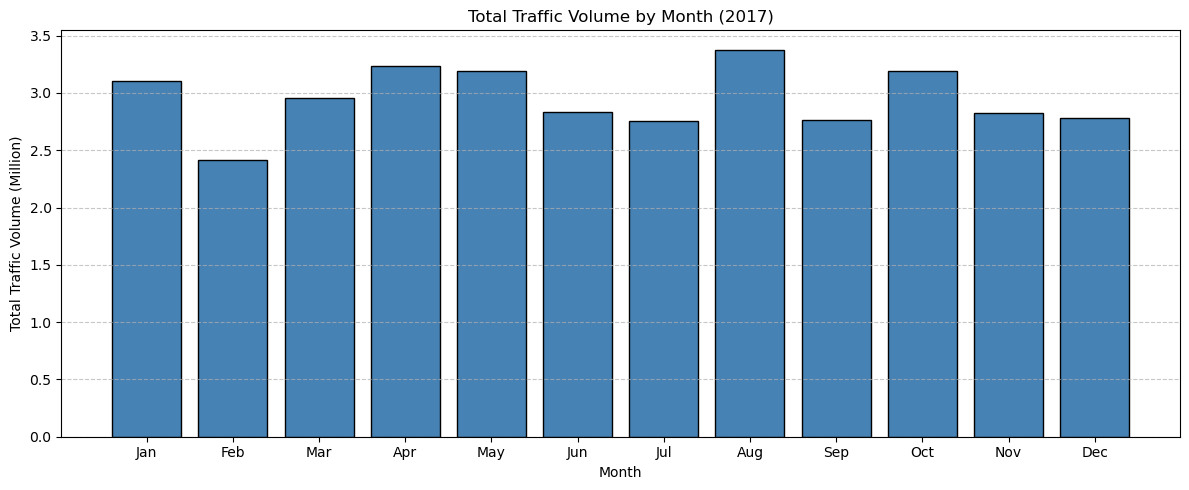

In [80]:
# Group by Month to get total traffic per month
monthly_total = traffic2017_df.groupby('Month')['traffic_volume'].sum()

# Convert to millions
monthly_total_million = monthly_total / 1_000_000

# Month names for x-axis
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Plot total monthly traffic
plt.figure(figsize=(12,5))
plt.bar(month_names, monthly_total_million.values, color='steelblue', edgecolor='black')
plt.title('Total Traffic Volume by Month (2017)')
plt.xlabel('Month')
plt.ylabel('Total Traffic Volume (Million)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

February: Typically the peak of the harsh Minnesota winters, temperature drops to -11. 
<br>
August: Busiest month because of great weather, Minnesota State Fair (one of the largest in the country), Construction Season.  

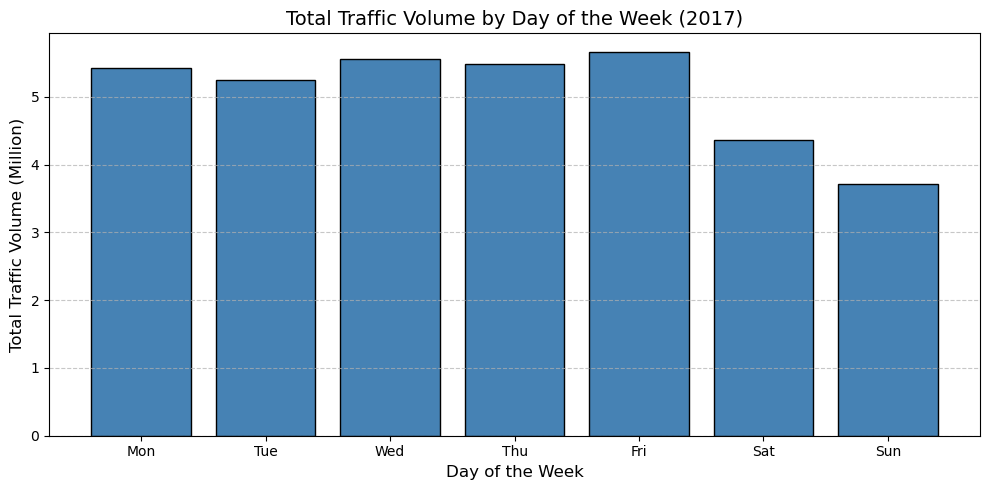

In [81]:
# Create a DayOfWeek column (0=Monday, 6=Sunday)
traffic2017_df['DayOfWeek'] = traffic2017_df['date_time'].dt.dayofweek

# Group by DayOfWeek
weekday_total = traffic2017_df.groupby('DayOfWeek')['traffic_volume'].sum()

# Convert to millions
weekday_total_million = weekday_total / 1_000_000

# Map numbers to day names
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Plot
plt.figure(figsize=(10,5))
plt.bar(day_names, weekday_total_million.values, color='steelblue', edgecolor='black')
plt.title('Total Traffic Volume by Day of the Week (2017)', fontsize=14)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Total Traffic Volume (Million)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


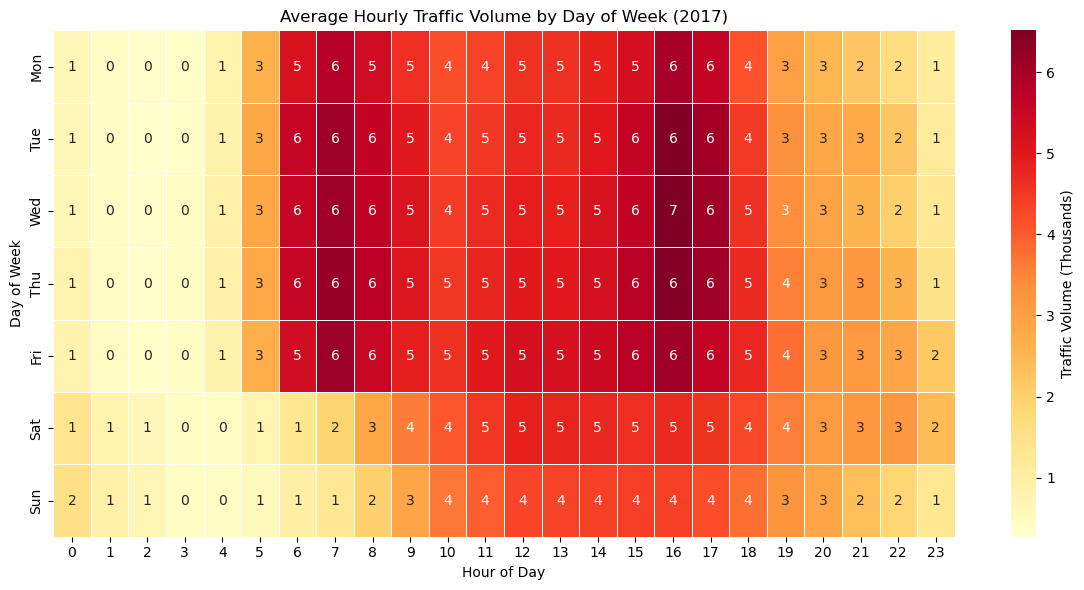

In [82]:
heatmap_data = traffic2017_df.groupby(['DayOfWeek','Hour'])['traffic_volume'].mean().unstack()

# Map day numbers to names
heatmap_data.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

# Scale values to thousands 
heatmap_data_k = heatmap_data / 1000  

plt.figure(figsize=(12,6))
sns.heatmap(
    heatmap_data_k, 
    cmap='YlOrRd', 
    linewidths=0.5, 
    annot=True, 
    fmt='.0f',      
    cbar_kws={'label': 'Traffic Volume (Thousands)'}
)
plt.title('Average Hourly Traffic Volume by Day of Week (2017)')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()


C:\Users\sassa\AppData\Local\Temp\ipykernel_39676\1294020838.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_avg = traffic2017_df.groupby('temp_bin')['traffic_volume'].mean()


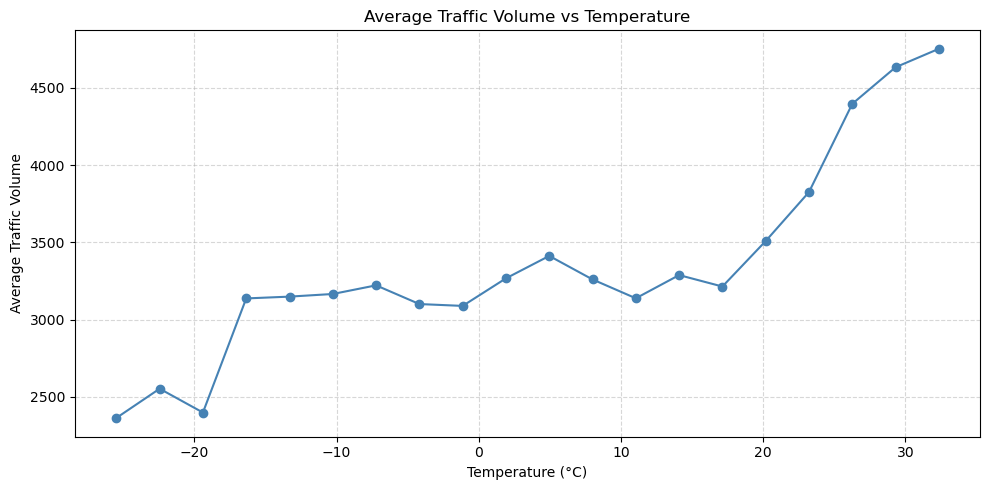

In [83]:
# Bin temperature into 20 bins
traffic2017_df['temp_bin'] = pd.cut(traffic2017_df['temp'], bins=20)
temp_avg = traffic2017_df.groupby('temp_bin')['traffic_volume'].mean()

plt.figure(figsize=(10,5))
plt.plot(
    temp_avg.index.categories.mid,  # midpoint of each bin
    temp_avg.values, 
    marker='o', 
    color='steelblue'
)
plt.title('Average Traffic Volume vs Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Average Traffic Volume')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Analysis

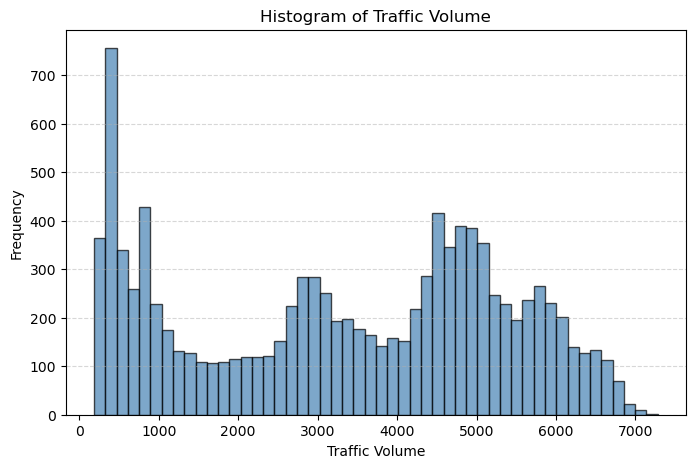

In [119]:
plt.figure(figsize=(8,5))
plt.hist(traffic2017_df['traffic_volume'], bins=50, color='steelblue', edgecolor='k', alpha=0.7)
plt.xlabel('Traffic Volume')
plt.ylabel('Frequency')
plt.title('Histogram of Traffic Volume')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


In [161]:
mean_tv = traffic2017_df['traffic_volume'].mean()
var_tv = traffic2017_df['traffic_volume'].var()
print(mean_tv, var_tv)


3340.7030645921736 3946208.7095389


There is overdispersion in data so Negative Binomial is more suitable than Poisson but we will still examine both

In [162]:
# Predictors List
X_columns = [
    'holiday',
    'temp',
    'clouds_all',
    'hour_sin', 'hour_cos',
    'weekday_sin', 'weekday_cos',
    'month_sin', 'month_cos',
    'weather_Cloudy', 'weather_Rain', 'weather_Snow', 'weather_Storm', 'weather_Other'
]

# Target variable
y = traffic2017_df['traffic_volume']


In [163]:
# Train-test split
X = traffic2017_df[X_columns]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)


(8484, 14) (2121, 14)
(8484,) (2121,)


## Poisson Model

In [164]:
# Add constant for intercept
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# Fit Poisson GLM
poisson_model = sm.GLM(y_train, X_train_const, family=sm.families.Poisson())
poisson_results = poisson_model.fit()

# View the summary
print(poisson_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         traffic_volume   No. Observations:                 8484
Model:                            GLM   Df Residuals:                     8469
Model Family:                 Poisson   Df Model:                           14
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.4520e+06
Date:                Mon, 08 Dec 2025   Deviance:                   4.8223e+06
Time:                        17:40:55   Pearson chi2:                 4.91e+06
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              7.9717      0.000   1.74e

In [165]:
# Key metrics
print("Poisson Full Model")
print("AIC:", poisson_results.aic)
print("Deviance:", poisson_results.deviance)
print("Pearson Chi2:", poisson_results.pearson_chi2)
print("Log-Likelihood:", poisson_results.llf)


Poisson Full Model
AIC: 4904046.997508524
Deviance: 4822291.1652821805
Pearson Chi2: 4910488.099141919
Log-Likelihood: -2452008.498754262


In [166]:
# Null model: only intercept
X_train_null = pd.DataFrame({'const': 1}, index=X_train.index)
X_test_null = pd.DataFrame({'const': 1}, index=X_test.index)

# Fit Poisson GLM null model
poisson_null_model = sm.GLM(y_train, X_train_null, family=sm.families.Poisson())
poisson_null_results = poisson_null_model.fit()

# View summary
print(poisson_null_results.summary())
# Check log-likelihood
print("Poisson Null Model Log-Likelihood:", poisson_null_results.llf)

                 Generalized Linear Model Regression Results                  
Dep. Variable:         traffic_volume   No. Observations:                 8484
Model:                            GLM   Df Residuals:                     8483
Model Family:                 Poisson   Df Model:                            0
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -6.0520e+06
Date:                Mon, 08 Dec 2025   Deviance:                   1.2022e+07
Time:                        17:40:55   Pearson chi2:                 1.01e+07
No. Iterations:                     5   Pseudo R-squ. (CS):          2.415e-12
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.1145      0.000   4.32e+04      0.0

In [167]:
R2_mcfadden = 1 - (poisson_results.llf / poisson_null_results.llf)
print("McFadden's R²:", R2_mcfadden)


McFadden's R²: 0.5948420126035476


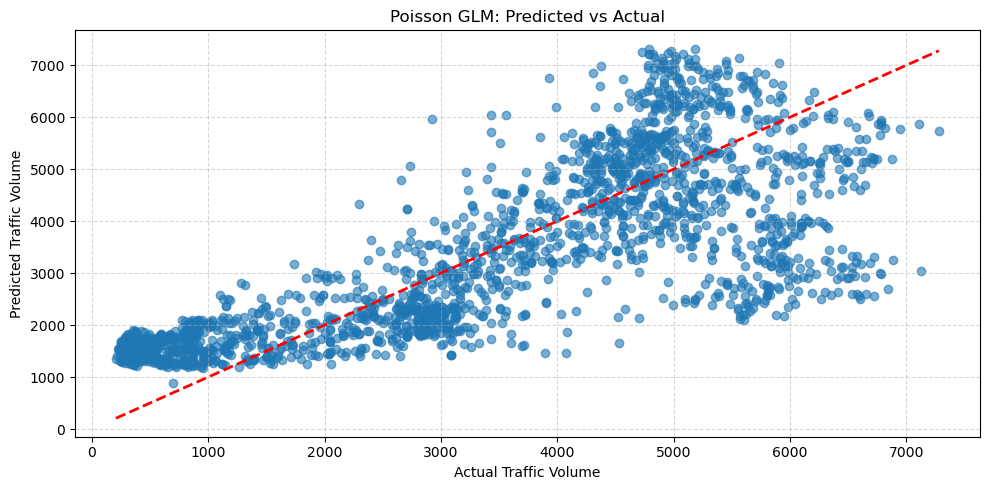

In [168]:
# Predict on test set
y_pred_poisson = poisson_results.predict(X_test_const)

plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_poisson, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Traffic Volume')
plt.ylabel('Predicted Traffic Volume')
plt.title('Poisson GLM: Predicted vs Actual')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


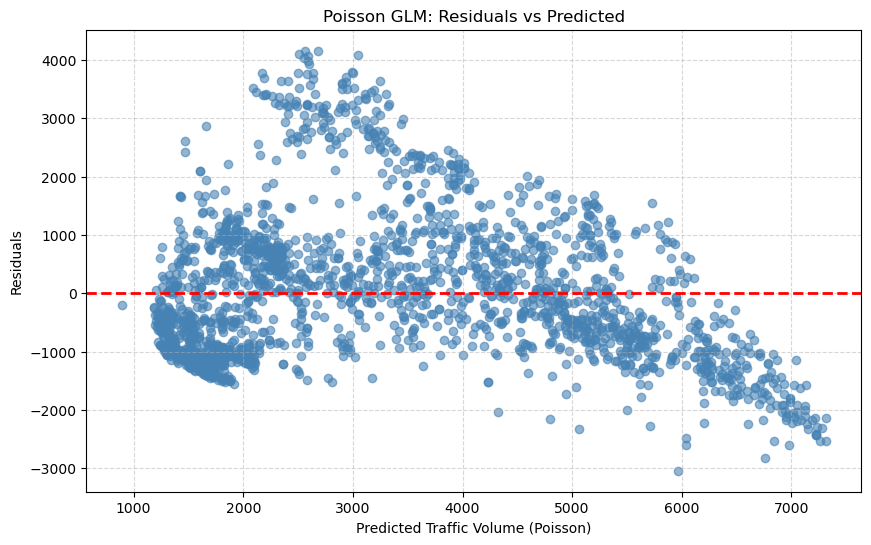

In [169]:
# Residuals for Poisson
poisson_residuals = y_test - poisson_results.predict(sm.add_constant(X_test))

plt.figure(figsize=(10,6))
plt.scatter(poisson_results.predict(sm.add_constant(X_test)), poisson_residuals, alpha=0.6, color='steelblue')
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted Traffic Volume (Poisson)')
plt.ylabel('Residuals')
plt.title('Poisson GLM: Residuals vs Predicted')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


The Poisson GLM captures the overall trend of traffic volume well, but due to overdispersion in the data, the model tends to underestimate high traffic hours and slightly overestimate low traffic hours. Most predicted values cluster around the observed values, yet the spread increases as traffic volume grows, indicating that a Poisson model may not fully account for the variance in the data.

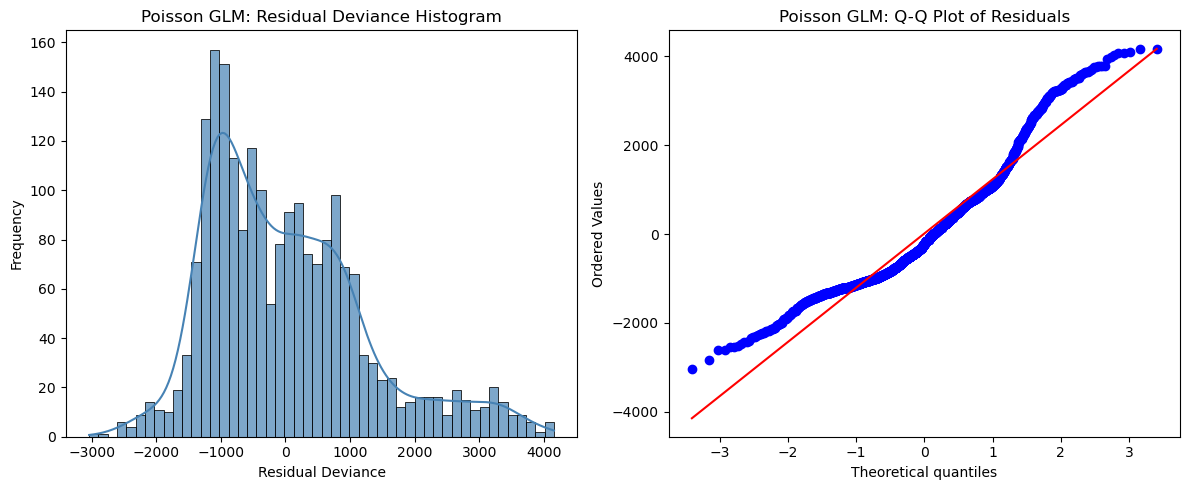

In [170]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Histogram of residual deviance
sns.histplot(poisson_residuals, bins=50, color='steelblue', alpha=0.7, kde=True, ax=axes[0])
axes[0].set_xlabel('Residual Deviance')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Poisson GLM: Residual Deviance Histogram')

# 2. Q-Q plot
stats.probplot(poisson_residuals, dist="norm", plot=axes[1])
axes[1].set_title('Poisson GLM: Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

## Negative Binomial

In [171]:
# Add constant
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# Fit Negative Binomial GLM
nb_model = sm.GLM(y_train, X_train_const, family=sm.families.NegativeBinomial(alpha=61.55))
nb_results = nb_model.fit()
print(nb_results.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:         traffic_volume   No. Observations:                 8484
Model:                            GLM   Df Residuals:                     8469
Model Family:        NegativeBinomial   Df Model:                           14
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.0173e+05
Date:                Mon, 08 Dec 2025   Deviance:                       41.239
Time:                        17:40:57   Pearson chi2:                     41.3
No. Iterations:                    10   Pseudo R-squ. (CS):           0.005507
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              7.9658      0.196     40.

In [172]:
# Negative Binomial Full Model metrics
print("Negative Binomial Full Model")
print("AIC:", nb_results.aic)
print("Deviance:", nb_results.deviance)
print("Pearson Chi2:", nb_results.pearson_chi2)
print("Log-Likelihood:", nb_results.llf)

Negative Binomial Full Model
AIC: 203497.47043343494
Deviance: 41.238805605814136
Pearson Chi2: 41.27239479984817
Log-Likelihood: -101733.73521671747


In [173]:
# Use the same index as y_train for the constant DataFrame
X_train_null = pd.DataFrame({'const': 1}, index=y_train.index)

# Fit Negative Binomial GLM null model
nb_null_model = sm.GLM(
    y_train,
    X_train_null,
    family=sm.families.NegativeBinomial(alpha=61.55)
)

nb_null_results = nb_null_model.fit()
print(nb_null_results.summary())
# Log-Likelihood for null model
print("Negative Binomial Null Model Log-Likelihood:", nb_null_results.llf)

                 Generalized Linear Model Regression Results                  
Dep. Variable:         traffic_volume   No. Observations:                 8484
Model:                            GLM   Df Residuals:                     8483
Model Family:        NegativeBinomial   Df Model:                            0
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.0176e+05
Date:                Mon, 08 Dec 2025   Deviance:                       88.086
Time:                        17:40:57   Pearson chi2:                     48.9
No. Iterations:                     5   Pseudo R-squ. (CS):          7.550e-14
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.1145      0.085     95.268      0.0

In [174]:
# McFadden's R² for NB
nb_mcfadden_r2 = 1 - (nb_results.llf / nb_null_results.llf)
print("McFadden's R²:", nb_mcfadden_r2)

McFadden's R²: 0.00023019083019526487


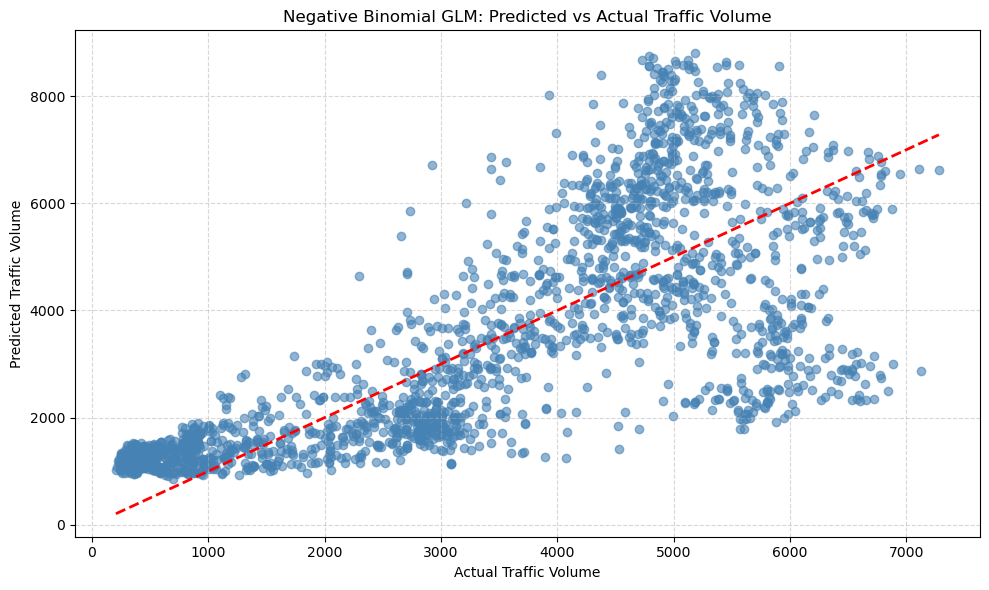

In [175]:
# Predict using the exact same columns used in training
y_pred_nb = nb_results.predict(X_test_const)


# Scatter plot: Actual vs Predicted
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred_nb, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # 45-degree line
plt.xlabel('Actual Traffic Volume')
plt.ylabel('Predicted Traffic Volume')
plt.title('Negative Binomial GLM: Predicted vs Actual Traffic Volume')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

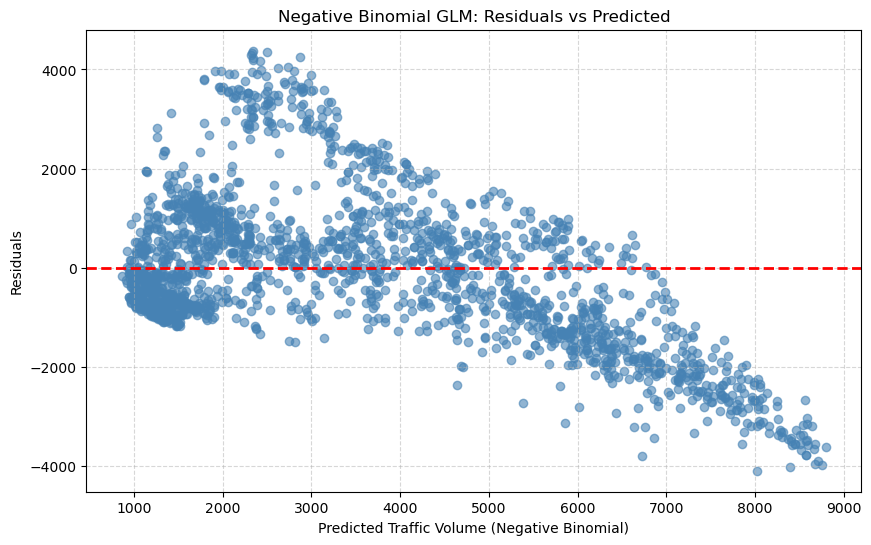

In [176]:
#Negative Binomial residuals
nb_pred = nb_results.predict(sm.add_constant(X_test))
nb_residuals = y_test - nb_pred

plt.figure(figsize=(10,6))
plt.scatter(nb_pred, nb_residuals, alpha=0.6, color='steelblue')
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted Traffic Volume (Negative Binomial)')
plt.ylabel('Residuals')
plt.title('Negative Binomial GLM: Residuals vs Predicted')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

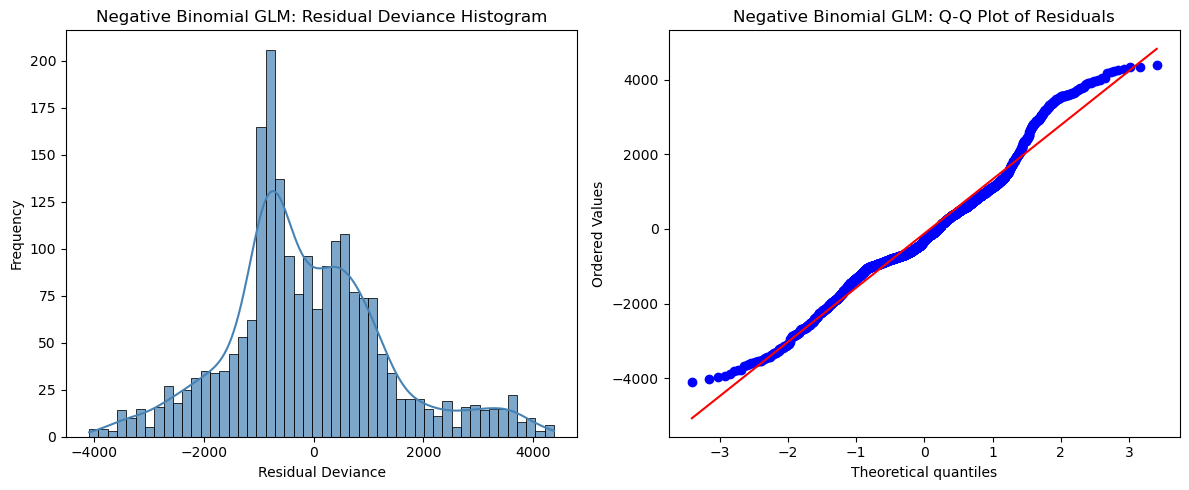

In [177]:
# Create 1x2 subplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Histogram of residual deviance
sns.histplot(nb_residuals, bins=50, color='steelblue', alpha=0.7, kde=True, ax=axes[0])
axes[0].set_xlabel('Residual Deviance')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Negative Binomial GLM: Residual Deviance Histogram')

# 2. Q-Q plot
stats.probplot(nb_residuals, dist="norm", plot=axes[1])
axes[1].set_title('Negative Binomial GLM: Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

In [178]:
# Likelihood Ratio Test between Poisson and Negative Binomial
LR_stat = 2 * (nb_results.llf - poisson_results.llf)
df_diff = 1  # difference in parameters (alpha)
from scipy.stats import chi2
p_value = 1 - chi2.cdf(LR_stat, df=df_diff)
print(LR_stat, p_value)

4700549.5270750895 0.0


This is extremely significant, meaning the Negative Binomial model fits the data much better than the Poisson model. The huge LR confirms that the overdispersion in the data is real and NB is necessary

In [179]:
from scipy.stats import chi2

df_resid = nb_results.df_resid
deviance = nb_results.deviance
pearson_chi2 = nb_results.pearson_chi2

chi2_critical = chi2.ppf(0.95, df_resid)
print("Deviance:", deviance, "Pearson Chi2:", pearson_chi2, "Chi2 critical:", chi2_critical)


Deviance: 41.238805605814136 Pearson Chi2: 41.27239479984817 Chi2 critical: 8684.202222132786


- Both Deviance and Pearson Chi² are much smaller than the critical x2 value.

- This tells us that, in absolute terms, the NB model does not overfit and is well within the expected range for our data.

- It also explains the very low R² (0.00023) — the model predicts the mean trend reasonably well, but traffic volume has a lot of unexplained variability that our predictors do not capture.